Spark 4.0.4 | Java 21.0.12 | Python 3.13.15 | master local[4,4]
Reading Excel (about 30-60 s) ...
Wrote 541,909 rows -> /content/sparkretail/data/online_retail.csv
Dataset ready: /content/sparkretail/data/online_retail.csv (44.9 MB)
InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTT
Definitions loaded.

1.1  Spark setup & execution model
Spark version       : 4.0.4
Master              : local[4,4] | default parallelism: 4
Application id      : local-1791199166471
Spark UI (internal) : http://127.0.0.1:4040
Driver    = this notebook's Python process (SparkContext, DAG scheduler, task scheduler)
Executors = JVM workers (threads in local mode) t

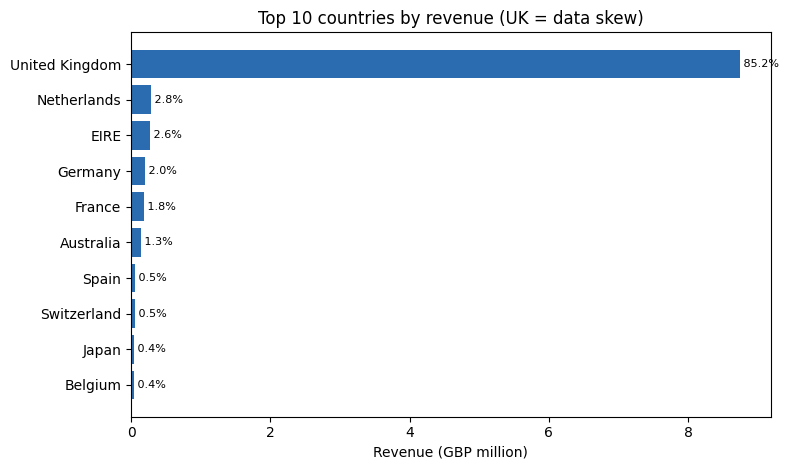

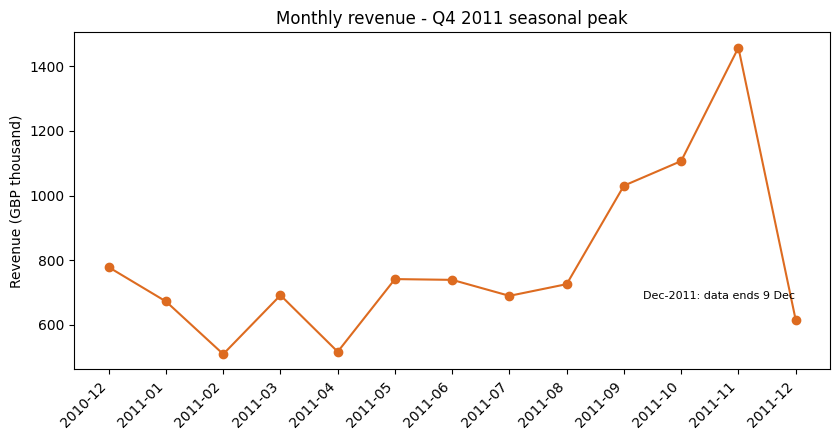

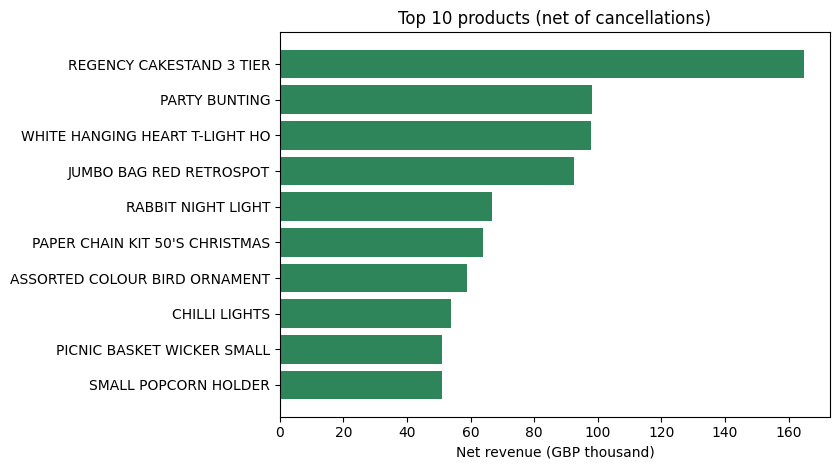

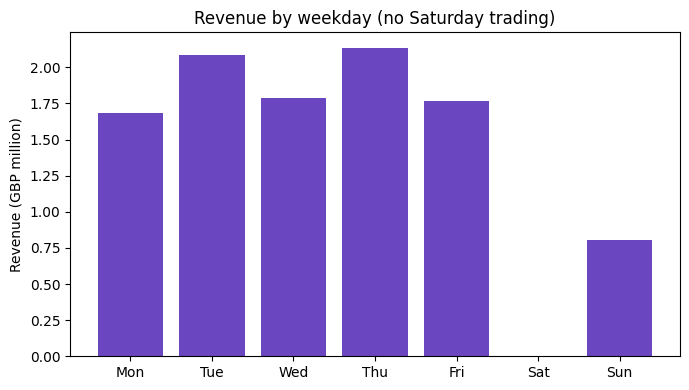

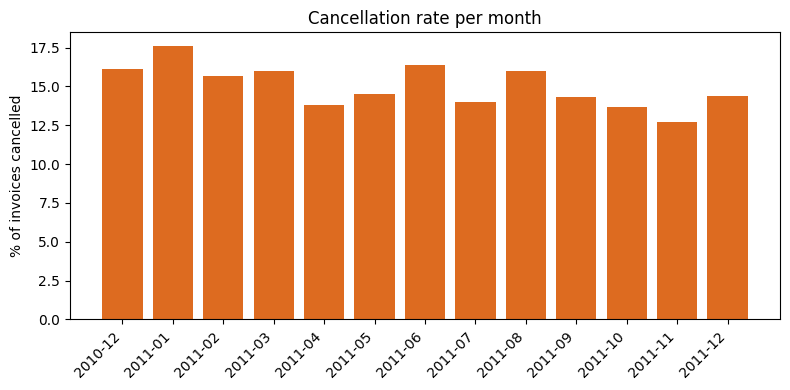

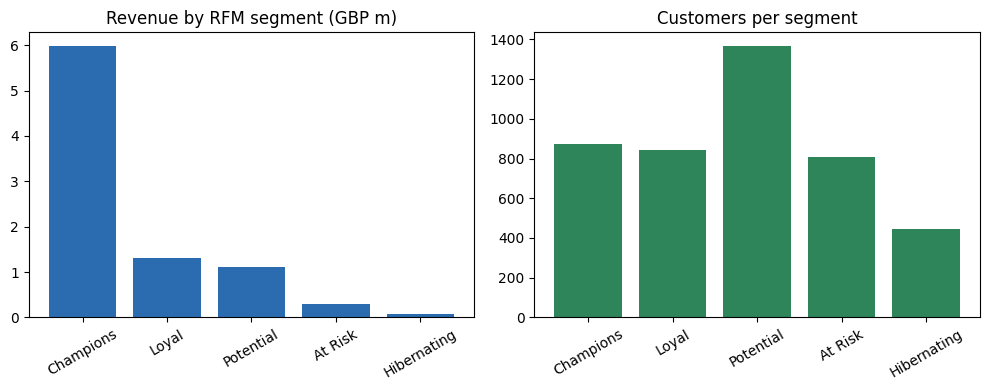

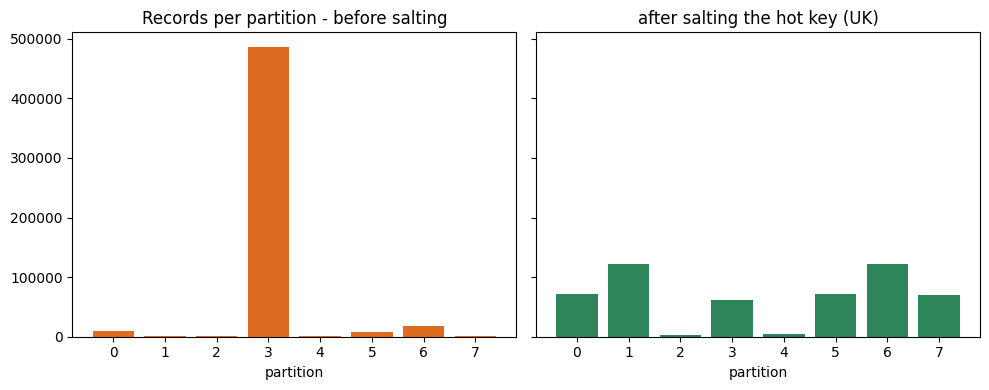

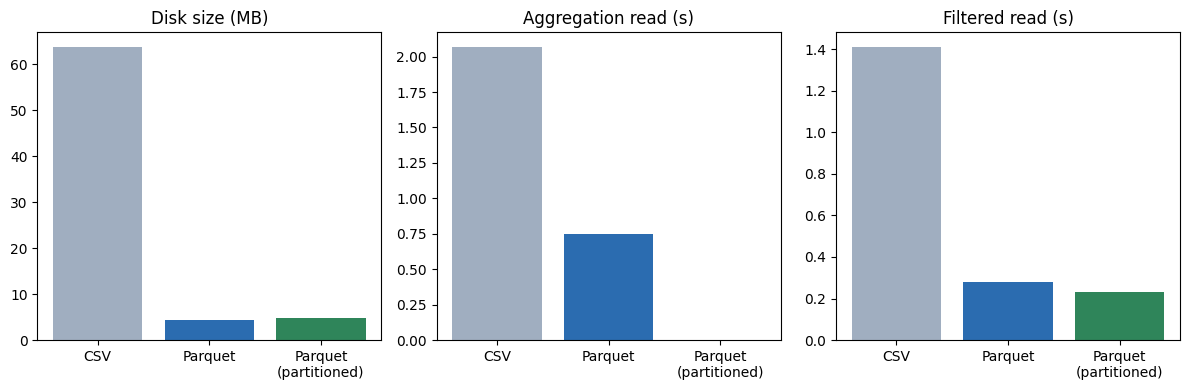

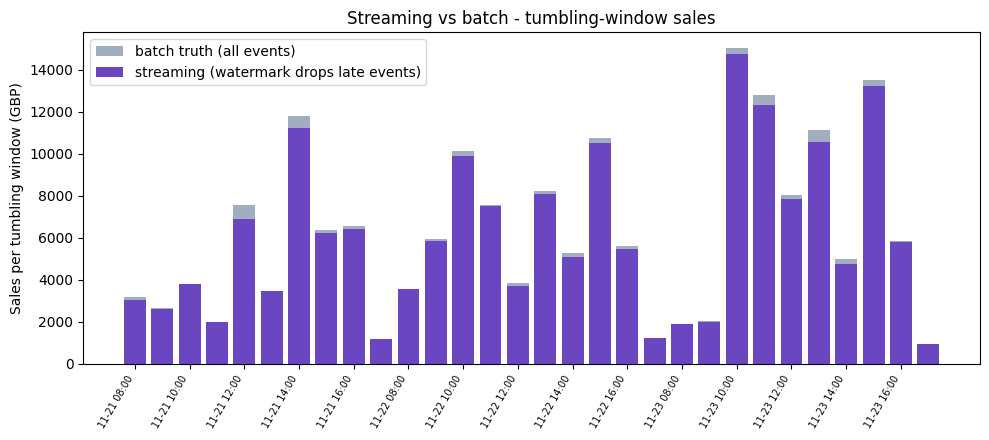

Results zipped: /content/sparkretail_results.zip (306 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# =====================================================================================
#  SparkRetail - End-to-End Sales Analytics Pipeline with Real-Time Windowed Insights
#  Apache Spark & Distributed Data Processing (26PMDS103)
#  Dataset: UCI Online Retail (Chen, Sain & Guo 2012, CC BY 4.0)
#  Uses the PySpark + Java.
# =====================================================================================

# -------------------------------------------------------------------------------------
# 0. Spark session, paths, helpers
# -------------------------------------------------------------------------------------
import os, sys, time, csv, json, shutil, threading, tempfile, warnings, re
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# ---- project paths
BASE       = "/content/sparkretail"
DATA_DIR   = f"{BASE}/data"
OUT        = f"{BASE}/output"
STREAM_IN  = f"{BASE}/streaming/input"
CKPT       = f"{BASE}/streaming/checkpoint"
RETAIL_CSV = f"{DATA_DIR}/online_retail.csv"
COUNTRY_CSV = f"{DATA_DIR}/country_region.csv"
for d in (DATA_DIR, OUT): os.makedirs(d, exist_ok=True)

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.sql.window import Window
from pyspark import TaskContext

if "spark" in globals():
    try: spark.stop()
    except Exception: pass

spark = (SparkSession.builder
         .appName("SparkRetail")
         .master("local[4,4]")
         .config("spark.driver.memory", "3g")
         .config("spark.driver.bindAddress", "127.0.0.1")
         .config("spark.driver.host", "127.0.0.1")
         .config("spark.sql.shuffle.partitions", 8)
         .config("spark.sql.session.timeZone", "UTC")
         .config("spark.sql.adaptive.enabled", "false")
         .config("spark.ui.showConsoleProgress", "false")
         .getOrCreate())
sc = spark.sparkContext
sc.setLogLevel("ERROR")

def banner(title):
    print("\n" + "=" * 78 + "\n" + title + "\n" + "=" * 78)

print("Spark", spark.version, "| Java", spark._jvm.System.getProperty("java.version"),
      "| Python", sys.version.split()[0], "| master", sc.master)

# -------------------------------------------------------------------------------------
# 1. Dataset: download real data -> CSV
# -------------------------------------------------------------------------------------
import io, zipfile, urllib.request

URLS = ["https://archive.ics.uci.edu/static/public/352/online+retail.zip",
        "https://raw.githubusercontent.com/aakashsyadav1999/online-retail-dataset/main/online%2Bretail.zip"]
RAW_XLSX = f"{DATA_DIR}/raw/Online Retail.xlsx"

# small reference (lookup) table: country -> region / continent
COUNTRY_REGION = {
 "United Kingdom": ("UK & Ireland", "Europe"), "EIRE": ("UK & Ireland", "Europe"), "Channel Islands": ("UK & Ireland", "Europe"),
 "Germany": ("Western Europe", "Europe"), "France": ("Western Europe", "Europe"), "Netherlands": ("Western Europe", "Europe"),
 "Belgium": ("Western Europe", "Europe"), "Switzerland": ("Western Europe", "Europe"), "Austria": ("Western Europe", "Europe"),
 "Spain": ("Southern Europe", "Europe"), "Portugal": ("Southern Europe", "Europe"), "Italy": ("Southern Europe", "Europe"),
 "Greece": ("Southern Europe", "Europe"), "Cyprus": ("Southern Europe", "Europe"), "Malta": ("Southern Europe", "Europe"),
 "Norway": ("Nordics", "Europe"), "Sweden": ("Nordics", "Europe"), "Denmark": ("Nordics", "Europe"),
 "Finland": ("Nordics", "Europe"), "Iceland": ("Nordics", "Europe"),
 "Poland": ("Eastern Europe", "Europe"), "Lithuania": ("Eastern Europe", "Europe"), "Czech Republic": ("Eastern Europe", "Europe"),
 "European Community": ("Europe (unspecified)", "Europe"),
 "Israel": ("Middle East", "Asia"), "Bahrain": ("Middle East", "Asia"), "Lebanon": ("Middle East", "Asia"),
 "United Arab Emirates": ("Middle East", "Asia"), "Saudi Arabia": ("Middle East", "Asia"),
 "Japan": ("Asia-Pacific", "Asia"), "Hong Kong": ("Asia-Pacific", "Asia"), "Singapore": ("Asia-Pacific", "Asia"),
 "Australia": ("Asia-Pacific", "Oceania"),
 "USA": ("North America", "Americas"), "Canada": ("North America", "Americas"), "Brazil": ("South America", "Americas"),
 "RSA": ("Africa", "Africa"), "Unspecified": ("Unspecified", "Unspecified"),
}

def get_excel():
    if os.path.exists(RAW_XLSX):
        return RAW_XLSX
    os.makedirs(os.path.dirname(RAW_XLSX), exist_ok=True)
    for u in URLS:
        try:
            print("Downloading", u)
            req = urllib.request.Request(u, headers={"User-Agent": "Mozilla/5.0"})
            blob = urllib.request.urlopen(req, timeout=180).read()
            with zipfile.ZipFile(io.BytesIO(blob)) as z:
                name = [n for n in z.namelist() if n.lower().endswith(".xlsx")][0]
                with open(RAW_XLSX, "wb") as f: f.write(z.read(name))
            return RAW_XLSX
        except Exception as e:
            print("  failed:", e)
    raise SystemExit("Could not download the dataset - upload 'Online Retail.xlsx' to " + os.path.dirname(RAW_XLSX))

if not os.path.exists(RETAIL_CSV):
    print("Reading Excel (about 30-60 s) ...")
    df0 = pd.read_excel(get_excel(), dtype={"InvoiceNo": str, "StockCode": str})
    df0["CustomerID"] = df0["CustomerID"].astype("Int64")        # 17850.0 -> 17850
    df0["Description"] = df0["Description"].str.strip()
    df0.to_csv(RETAIL_CSV, index=False, date_format="%Y-%m-%d %H:%M:%S", quoting=csv.QUOTE_MINIMAL)
    print(f"Wrote {len(df0):,} rows -> {RETAIL_CSV}")

with open(COUNTRY_CSV, "w", newline="") as f:
    w = csv.writer(f); w.writerow(["country", "region", "continent"])
    for c, (r, k) in sorted(COUNTRY_REGION.items()): w.writerow([c, r, k])

print("Dataset ready:", RETAIL_CSV, f"({os.path.getsize(RETAIL_CSV)/1048576:.1f} MB)")
print(open(RETAIL_CSV).read(400))

# -------------------------------------------------------------------------------------
# 2. Shared definitions (schema, parser, business rules)
# -------------------------------------------------------------------------------------
# Service / fee codes - not physical products (postage, manual adjustments, bank charges ...)
NON_PRODUCT = {"POST", "D", "M", "m", "DOT", "BANK CHARGES", "CRUK", "S", "B", "AMAZONFEE", "PADS", "C2"}
SNAPSHOT_DATE = "2011-12-10"          # day after the last transaction; used for RFM recency
BULK_QTY, BULK_DISCOUNT = 24, 0.10    # WHAT-IF promotion used for the derived `discounted_price` column

SCHEMA = T.StructType([
    T.StructField("invoice_no", T.StringType()),    T.StructField("stock_code", T.StringType()),
    T.StructField("description", T.StringType()),   T.StructField("quantity", T.IntegerType()),
    T.StructField("invoice_ts", T.TimestampType()), T.StructField("unit_price", T.DoubleType()),
    T.StructField("customer_id", T.StringType()),   T.StructField("country", T.StringType()),
])

def parse_partition(lines):
    """RDD parser. csv.reader (not split(',')) because product descriptions contain quoted commas."""
    for row in csv.reader(lines):
        if not row or row[0] == "InvoiceNo":
            continue
        yield (row[0], row[1], row[2] or None, int(row[3]),
               datetime.strptime(row[4], "%Y-%m-%d %H:%M:%S"), float(row[5]), row[6] or None, row[7])

def load_rdd(sc, path, min_partitions=8):
    return sc.textFile(path, min_partitions).mapPartitions(parse_partition)

def is_valid_sale(r):
    """Plain-python rule used by the RDD module: a real, positive product sale."""
    return (not r[0].startswith("C")) and r[3] > 0 and r[5] > 0 and r[1] not in NON_PRODUCT

def add_derived(df):
    return (df
        .withColumn("is_cancel", F.col("invoice_no").startswith("C"))
        .withColumn("is_product", ~F.col("stock_code").isin(*NON_PRODUCT))
        .withColumn("line_total", (F.col("quantity") * F.col("unit_price")).cast("decimal(18,2)"))
        .withColumn("discounted_price",
                    F.round(F.when(F.col("quantity") >= BULK_QTY, F.col("unit_price") * (1 - BULK_DISCOUNT))
                             .otherwise(F.col("unit_price")), 2))
        .withColumn("discounted_total", (F.col("quantity") * F.col("discounted_price")).cast("decimal(18,2)"))
        .withColumn("invoice_month", F.date_format("invoice_ts", "yyyy-MM"))
        .withColumn("invoice_date", F.to_date("invoice_ts"))
        .withColumn("hour", F.hour("invoice_ts"))
        .withColumn("weekday", F.date_format("invoice_ts", "E")))

def valid_sales(df):
    """Sales lines used for revenue analytics (no cancellations, returns, zero-price or fee lines)."""
    return df.filter((~F.col("is_cancel")) & (F.col("quantity") > 0) & (F.col("unit_price") > 0) & F.col("is_product"))

def read_transactions(spark, path):
    """All 541,909 lines as a typed DataFrame + derived columns."""
    return add_derived(spark.read.csv(path, header=True, schema=SCHEMA, timestampFormat="yyyy-MM-dd HH:mm:ss"))

print("Definitions loaded.")

# -------------------------------------------------------------------------------------
# MODULE 1 - RDD processing: 1.1 setup
# -------------------------------------------------------------------------------------
banner("1.1  Spark setup & execution model")
print("Spark version       :", spark.version)
print("Master              :", sc.master, "| default parallelism:", sc.defaultParallelism)
print("Application id      :", sc.applicationId)
print("Spark UI (internal) :", sc.uiWebUrl)
print("Driver    = this notebook's Python process (SparkContext, DAG scheduler, task scheduler)")
print("Executors = JVM workers (threads in local mode) that run Tasks on partitions")

# -------------------------------------------------------------------------------------
# MODULE 1 - 1.2 lazy evaluation, narrow transformations, data quality
# -------------------------------------------------------------------------------------
banner("1.2  Load CSV as RDD - lazy evaluation & narrow transformations")
t = time.time()
records = load_rdd(sc, RETAIL_CSV, 8).cache()                  # nothing runs yet
valid   = records.filter(is_valid_sale)                        # narrow
revenue = valid.map(lambda r: (r[7], r[3] * r[5]))             # narrow -> (country, revenue)
print(f"Defined textFile->mapPartitions->filter->map in {time.time()-t:.3f}s (LAZY: no data read yet)")
t = time.time(); n_raw = records.count()
print(f"First ACTION count() = {n_raw:,} rows in {time.time()-t:.2f}s (reads + parses + caches)")
t = time.time(); records.count()
print(f"Second count() from cache in {time.time()-t:.2f}s")
print("Partitions:", records.getNumPartitions(), "| sample record:", records.first())

# data-quality profile in ONE pass (map to flags, then reduce)
flags = (records.map(lambda r: (1, r[0].startswith("C"), r[3] <= 0, r[5] <= 0, r[6] is None, r[2] is None, r[1] in NON_PRODUCT))
                .map(lambda f: tuple(int(x) for x in f))
                .reduce(lambda a, b: tuple(x + y for x, y in zip(a, b))))
names = ["rows", "cancellation invoices (C...)", "quantity <= 0", "unit price <= 0", "missing CustomerID",
         "missing Description", "non-product codes (POST, M, ...)"]
print("\nData-quality profile of the REAL data:")
for k, v in zip(names, flags):
    print(f"  {k:<34}{v:>9,}  ({v / flags[0] * 100:5.2f}%)")
n_valid = valid.count()
print(f"  {'VALID sales lines used for revenue':<34}{n_valid:>9,}  ({n_valid / n_raw * 100:5.2f}%)")

# -------------------------------------------------------------------------------------
# MODULE 1 - 1.3 groupByKey vs reduceByKey (shuffle bytes via Spark REST API)
# -------------------------------------------------------------------------------------
banner("1.3  Wide transformation: groupByKey vs reduceByKey (shuffle study)")
import requests

def stage_ids():
    port = sc.uiWebUrl.rsplit(":", 1)[1].strip("/")
    api = f"http://localhost:{port}/api/v1/applications/{sc.applicationId}/stages"
    return api, requests.get(api, timeout=10).json()

def measure(action, runs=3):
    """Runs `action` `runs` times; returns (result, best_time, shuffle_write_bytes of the FIRST run, from the Spark REST API)."""
    best, sw, out = 1e9, None, None
    for i in range(runs):
        try: api, before = stage_ids(); before = {s["stageId"] for s in before}
        except Exception: api, before = None, None
        t = time.time(); out = action(); dt = time.time() - t; best = min(best, dt)
        if i == 0 and api:
            time.sleep(1.5)                                    # let the UI listener finish updating metrics
            try: sw = sum(s.get("shuffleWriteBytes", 0) for s in requests.get(api, timeout=10).json() if s["stageId"] not in before)
            except Exception: sw = None
    return out, best, sw

revenue.cache().count()
g, t_g, sw_g = measure(lambda: revenue.groupByKey().mapValues(sum).collect())
r, t_r, sw_r = measure(lambda: revenue.reduceByKey(lambda a, b: a + b).collect())
dg, dr = dict(g), dict(r)
assert dg.keys() == dr.keys() and all(abs(dg[k] - dr[k]) < 1e-3 * max(1, abs(dr[k])) for k in dg), "results differ"

print(f"  groupByKey  best of 3: {t_g:6.2f}s   shuffle write: {'n/a' if sw_g is None else f'{sw_g/1024:,.0f} KB'}")
print(f"  reduceByKey best of 3: {t_r:6.2f}s   shuffle write: {'n/a' if sw_r is None else f'{sw_r/1024:,.0f} KB'}")
print(f"  -> time ratio {t_g / t_r:.2f}x, identical results")
if sw_g and sw_r:
    print(f"  -> reduceByKey moved {sw_g / max(sw_r, 1):,.0f}x LESS data through the shuffle (the real reason it is faster)")
print("  reduceByKey combines map-side BEFORE the shuffle; groupByKey ships every record, then sums.\n")

tot = sum(dr.values())
print("  Revenue by country - top 8 (GBP):")
for k, v in sorted(dr.items(), key=lambda x: -x[1])[:8]:
    print(f"    {k:<18}{v:>14,.2f}  {v / tot * 100:5.1f}%")
print("  (United Kingdom dominates -> real data skew, exploited in Module 2)")

top_products = (valid.map(lambda r: (r[1], (r[3] * r[5], r[3], r[2])))
                .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1], a[2] or b[2]))
                .takeOrdered(5, key=lambda kv: -kv[1][0]))
print("\n  Top 5 products by revenue (reduceByKey + takeOrdered):")
for code_, (rev, units, desc) in top_products:
    print(f"    {code_:<8}{(desc or '')[:34]:<36}{rev:>12,.2f}  {units:>8,} units")

# -------------------------------------------------------------------------------------
# MODULE 1 - 1.4 lineage / DAG / Job-Stage-Task
# -------------------------------------------------------------------------------------
banner("1.4  Lineage graph & DAG")
print(revenue.reduceByKey(lambda a, b: a + b).toDebugString().decode())
print("\n  Job   = created by each ACTION (count/collect/...).")
print("  Stage = pipelined narrow transformations; a new stage starts at each SHUFFLE (indent break above).")
print("  Task  = one stage x one partition (here 8 partitions -> 8 tasks per stage).")
st = sc.statusTracker()
for jid in sorted(st.getJobIdsForGroup())[-3:]:
    ji = st.getJobInfo(jid)
    if ji:
        tasks = sum(st.getStageInfo(s).numTasks for s in ji.stageIds if st.getStageInfo(s))
        print(f"  Job {jid}: stages={list(ji.stageIds)} total tasks={tasks} status={ji.status}")

# -------------------------------------------------------------------------------------
# MODULE 1 - 1.5 fault tolerance
# -------------------------------------------------------------------------------------
banner("1.5  Fault tolerance: simulated executor/task failure")
marker_dir = tempfile.mkdtemp(prefix="sparkretail_fail_")
lines = sc.textFile(RETAIL_CSV, 8)

def flaky(it):
    ctx = TaskContext.get()
    if ctx.partitionId() == 2 and ctx.attemptNumber() < 2:       # partition 2 crashes on attempts 0 and 1
        open(os.path.join(marker_dir, f"fail_p2_attempt{ctx.attemptNumber()}"), "w").close()
        raise RuntimeError("Simulated executor failure")
    yield from parse_partition(it)

sc.setLogLevel("OFF")                                             # hide the expected executor stack traces
got = lines.mapPartitions(flaky).count()
sc.setLogLevel("ERROR")
print("  Injected failures:", sorted(os.listdir(marker_dir)))
print(f"  Expected {n_raw:,} rows | after recovery {got:,} rows -> "
      f"{'RESULT CORRECT - no data lost' if got == n_raw else 'MISMATCH'}")
print("  Spark re-ran ONLY the failed task, rebuilding its partition from the lineage (textFile -> parse).")
print("  On a real cluster you can kill a worker JVM mid-job and watch the same recovery.")

# -------------------------------------------------------------------------------------
# MODULE 2 - DataFrames & joins: 2.1 RDD -> DataFrame, derived columns
# -------------------------------------------------------------------------------------
banner("2.1  RDD -> schema-based DataFrame, cleaning & derived columns")
rdd = load_rdd(sc, RETAIL_CSV)
raw = add_derived(spark.createDataFrame(rdd, SCHEMA))            # RDD -> DataFrame with explicit schema
sales = valid_sales(raw).cache()
n_raw2, n_sales = raw.count(), sales.count()
print(f"Raw lines={n_raw2:,}   valid sales lines={n_sales:,}  (removed {n_raw2 - n_sales:,}: cancellations, returns, fees, zero prices)")
sales.printSchema()
sales.select("invoice_no", "description", "quantity", "unit_price", "discounted_price", "line_total",
             "discounted_total", "invoice_month").show(6, truncate=30)
print(f"`discounted_price` = WHAT-IF bulk promotion: {int(BULK_DISCOUNT*100)}% off lines with quantity >= {BULK_QTY}.")
w = sales.agg(F.sum("line_total").alias("list"), F.sum("discounted_total").alias("promo")).first()
print(f"Total revenue GBP {w['list']:,.2f}  ->  with bulk promo GBP {w['promo']:,.2f}  (promo cost GBP {w['list'] - w['promo']:,.2f})")

# -------------------------------------------------------------------------------------
# MODULE 2 - 2.2 RFM customer dimension + inner join
# -------------------------------------------------------------------------------------
banner("2.2  Customer dimension (RFM segments) + inner join")
snap = F.lit(SNAPSHOT_DATE).cast("date")
cust = (sales.filter(F.col("customer_id").isNotNull()).groupBy("customer_id")
        .agg(F.countDistinct("invoice_no").alias("orders"),
             F.round(F.sum("line_total").cast("double"), 2).alias("spend"),
             F.datediff(snap, F.max("invoice_date")).alias("recency_days")))
r_ = F.ntile(4).over(Window.orderBy(F.desc("recency_days")))     # 4 = most recent
f_ = F.ntile(4).over(Window.orderBy("orders"))
m_ = F.ntile(4).over(Window.orderBy("spend"))
cust = (cust.withColumn("r", r_).withColumn("f", f_).withColumn("m", m_)
        .withColumn("rfm", F.col("r") + F.col("f") + F.col("m"))
        .withColumn("segment", F.when(F.col("rfm") >= 11, "Champions").when(F.col("rfm") >= 9, "Loyal")
                    .when(F.col("rfm") >= 6, "Potential").when(F.col("rfm") >= 4, "At Risk").otherwise("Hibernating"))
        .cache())
print(f"Customer dimension built from the transactions: {cust.count():,} customers")
cust.groupBy("segment").agg(F.count("*").alias("customers"), F.round(F.avg("spend"), 2).alias("avg_spend"),
                            F.round(F.avg("recency_days"), 1).alias("avg_recency_days")).orderBy(F.desc("avg_spend")).show()

joined = sales.join(cust, "customer_id", "inner")
n_j = joined.count()
print(f"Inner join sales x customers: {n_j:,} of {n_sales:,} lines kept")
print(f"  -> {n_sales - n_j:,} lines ({(n_sales - n_j) / n_sales * 100:.1f}%) have no CustomerID (guest checkout) and drop out of an INNER join.")
print("Revenue by RFM segment:")
seg = (joined.groupBy("segment").agg(F.round(F.sum("line_total").cast("double"), 2).alias("revenue"),
                                     F.countDistinct("customer_id").alias("customers")).orderBy(F.desc("revenue")))
seg.show()
pd.DataFrame([r.asDict() for r in seg.collect()]).to_csv(f"{OUT}/rfm_segments.csv", index=False)

# -------------------------------------------------------------------------------------
# MODULE 2 - 2.3 broadcast join
# -------------------------------------------------------------------------------------
banner("2.3  Broadcast join: sales x country->region lookup (38 rows)")
regions = spark.read.csv(COUNTRY_CSV, header=True)
sales.count()

def timed(label, df, runs=3):
    ts = []
    for _ in range(runs):
        t = time.time(); n = df.count(); ts.append(time.time() - t)
    print(f"  [{label:<24}] rows={n:>9,}  best of {runs}: {min(ts):5.2f}s")
    return min(ts)

spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)       # force a shuffle (sort-merge) join
t_smj = timed("sort-merge join", sales.join(regions, "country"))
t_bhj = timed("broadcast hash join", sales.join(F.broadcast(regions), "country"))
print(f"  Broadcast speed-up: {t_smj / t_bhj:.2f}x   (lookup is copied to every executor; the big side is not shuffled)")
print("\n  Physical plan with broadcast hint (look for BroadcastHashJoin / BroadcastExchange):")
plan = sales.join(F.broadcast(regions), "country")._jdf.queryExecution().executedPlan().toString()
print("\n".join("   " + l[:150] for l in plan.splitlines() if any(k in l for k in ("Join", "Broadcast", "Scan"))))
print("\nRevenue by region (via broadcast join):")
(sales.join(F.broadcast(regions), "country").groupBy("region")
      .agg(F.round(F.sum("line_total").cast("double"), 2).alias("revenue"), F.count("*").alias("lines"))
      .orderBy(F.desc("revenue")).show())

# -------------------------------------------------------------------------------------
# MODULE 2 - 2.4 data skew + key salting
# -------------------------------------------------------------------------------------
banner("2.4  Data skew in the REAL data: United Kingdom dominates")

def partition_sizes(df, col, n=8):
    return df.repartition(n, col).rdd.glom().map(len).collect()
def ratio(sizes):
    return max(sizes) / (sum(sizes) / len(sizes))

dist = sales.groupBy("country").count().orderBy(F.desc("count"))
dist.show(5)
top = dist.first()
print(f"  '{top['country']}' holds {top['count'] / n_sales * 100:.1f}% of all sales lines.")
before = partition_sizes(sales, "country")
print("  Records per partition after hash-partitioning on country:", before)
print(f"  max/avg partition size = {ratio(before):.2f}  (ideal = 1.0; one task gets almost everything)")

agg = lambda d: (d.groupBy("country", "region").agg(F.round(F.sum("line_total").cast("double"), 2).alias("revenue"),
                                                     F.count("*").alias("lines")))
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)
print("\n  (a) Baseline - shuffle (sort-merge) join on the skewed key")
t0 = time.time(); base = {r.country: (r.revenue, r.lines) for r in agg(sales.join(regions, "country")).collect()}
print(f"      {time.time() - t0:.2f}s")

print("  (b) Mitigation 1 - broadcast join (no shuffle of the big side)")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", 10 * 1024 * 1024)
t0 = time.time(); bc = {r.country: (r.revenue, r.lines) for r in agg(sales.join(F.broadcast(regions), "country")).collect()}
print(f"      {time.time() - t0:.2f}s")

print("  (c) Mitigation 2 - key salting (only the hot key is split into N sub-keys; use when the dim is too big to broadcast)")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)
N, HOT = 8, top["country"]
fact_s = sales.withColumn("salt", F.when(F.col("country") == HOT, (F.rand(42) * N).cast("int")).otherwise(F.lit(0)))
salts = spark.range(0, N).select(F.col("id").cast("int").alias("salt"))
dim_s = (regions.filter(F.col("country") != HOT).withColumn("salt", F.lit(0))
         .unionByName(regions.filter(F.col("country") == HOT).crossJoin(salts)))      # hot key replicated N times
t0 = time.time(); sl = {r.country: (r.revenue, r.lines) for r in agg(fact_s.join(dim_s, ["country", "salt"])).collect()}
print(f"      {time.time() - t0:.2f}s")

same = all(base[k][1] == bc[k][1] == sl[k][1] and abs(base[k][0] - bc[k][0]) < 0.05 and abs(base[k][0] - sl[k][0]) < 0.05 for k in base)
print(f"\n  Results identical across (a), (b), (c)? -> {same}")
after = (fact_s.withColumn("key", F.concat_ws("_", "country", F.col("salt").cast("string")))
         .repartition(8, "key").rdd.glom().map(len).collect())
print("  Partition sizes before salting:", before)
print("  Partition sizes after  salting:", after)
print(f"  max/avg ratio: {ratio(before):.2f}  ->  {ratio(after):.2f}")
pd.DataFrame({"partition": range(len(before)), "before_salting": before, "after_salting": after}).to_csv(f"{OUT}/skew_partitions.csv", index=False)
print("  Note: in local mode every 'executor' shares the same CPU, so wall-clock gains are modest; the partition-balance")
print("  ratio is the real evidence of skew (on a cluster: the task-duration spread in the Spark UI).")
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", 10 * 1024 * 1024)

# -------------------------------------------------------------------------------------
# MODULE 3 - Spark SQL & storage: 3.1 temp views
# -------------------------------------------------------------------------------------
banner("3.1  Register temp views")
spark.catalog.clearCache()                                        # free memory from Module 2
tx = read_transactions(spark, RETAIL_CSV)
tx.createOrReplaceTempView("transactions")                        # every line (incl. cancellations)
valid_sales(tx).createOrReplaceTempView("sales")                  # valid sales lines
spark.read.csv(COUNTRY_CSV, header=True).createOrReplaceTempView("country_region")
print("Views:", sorted(t.name for t in spark.catalog.listTables()))

def run(name, title, sql, n=20):
    print(f"\n{name}. {title}")
    df = spark.sql(sql)
    df.show(n, truncate=False)
    pd.DataFrame([r.asDict() for r in df.collect()]).to_csv(f"{OUT}/{name}.csv", index=False)

# -------------------------------------------------------------------------------------
# MODULE 3 - 3.2 analytical queries
# -------------------------------------------------------------------------------------
banner("3.2  Analytical queries (Spark SQL)")
run("q1_country_revenue", "Revenue by country - top 10, with share of total", """
    SELECT s.country, r.region, COUNT(DISTINCT s.invoice_no) AS orders, ROUND(SUM(s.line_total),2) AS revenue,
           ROUND(100*SUM(s.line_total)/SUM(SUM(s.line_total)) OVER (),1) AS pct_of_total
    FROM sales s JOIN country_region r ON s.country = r.country
    GROUP BY s.country, r.region ORDER BY revenue DESC LIMIT 10""")
run("q2_top_products", "Top 10 products by GROSS revenue (valid sales lines only)", """
    SELECT stock_code, MAX(description) AS product, SUM(quantity) AS units, ROUND(SUM(line_total),2) AS revenue,
           COUNT(DISTINCT invoice_no) AS orders
    FROM sales GROUP BY stock_code ORDER BY revenue DESC LIMIT 10""")
run("q2b_top_products_net", "Top products NET of cancellations - note how the gross #2 product vanishes", """
    SELECT stock_code, MAX(description) AS product, SUM(quantity) AS net_units, ROUND(SUM(line_total),2) AS net_revenue
    FROM transactions WHERE is_product AND unit_price > 0 GROUP BY stock_code ORDER BY net_revenue DESC LIMIT 10""")
run("q3_monthly_trend", "Monthly revenue with month-over-month growth (LAG window; Dec-2011 is a partial month)", """
    WITH m AS (SELECT invoice_month, SUM(line_total) AS revenue, COUNT(DISTINCT invoice_no) AS orders,
                      COUNT(DISTINCT customer_id) AS customers FROM sales GROUP BY invoice_month)
    SELECT invoice_month, ROUND(revenue,2) AS revenue, orders, customers,
           ROUND(100*(revenue - LAG(revenue) OVER (ORDER BY invoice_month)) / LAG(revenue) OVER (ORDER BY invoice_month),1) AS mom_pct
    FROM m ORDER BY invoice_month""", 15)
run("q4_top_product_per_country", "Best-selling product in each of the top-5 countries - RANK() OVER (PARTITION BY ...)", """
    WITH top5 AS (SELECT country FROM sales GROUP BY country ORDER BY SUM(line_total) DESC LIMIT 5),
    p AS (SELECT country, MAX(description) AS product, SUM(line_total) AS revenue,
                 RANK() OVER (PARTITION BY country ORDER BY SUM(line_total) DESC) AS rnk
          FROM sales WHERE country IN (SELECT country FROM top5) GROUP BY country, stock_code)
    SELECT country, product, ROUND(revenue,2) AS revenue FROM p WHERE rnk = 1 ORDER BY revenue DESC""")
run("q5_weekday_hour", "When do customers buy? Revenue by weekday", """
    SELECT weekday, COUNT(DISTINCT invoice_no) AS orders, ROUND(SUM(line_total),2) AS revenue
    FROM sales GROUP BY weekday ORDER BY revenue DESC""")
run("q6_cancellations", "Cancellation rate per month (invoices starting with 'C')", """
    SELECT invoice_month, COUNT(DISTINCT CASE WHEN is_cancel THEN invoice_no END) AS cancelled_invoices,
           COUNT(DISTINCT invoice_no) AS all_invoices,
           ROUND(100*COUNT(DISTINCT CASE WHEN is_cancel THEN invoice_no END)/COUNT(DISTINCT invoice_no),1) AS cancel_pct
    FROM transactions GROUP BY invoice_month ORDER BY invoice_month""", 15)
run("q7_top_customers", "Top 10 customers - spend and share of identified revenue", """
    SELECT customer_id, COUNT(DISTINCT invoice_no) AS orders, ROUND(SUM(line_total),2) AS spend,
           ROUND(100*SUM(line_total)/(SELECT SUM(line_total) FROM sales WHERE customer_id IS NOT NULL),1) AS pct_of_identified_revenue
    FROM sales WHERE customer_id IS NOT NULL GROUP BY customer_id ORDER BY spend DESC LIMIT 10""")

# -------------------------------------------------------------------------------------
# MODULE 3 - 3.3 Catalyst optimizer
# -------------------------------------------------------------------------------------
banner("3.3  Catalyst optimizer - explain(True)")
q = spark.sql("""SELECT country, SUM(rev) AS total FROM
                 (SELECT country, quantity * unit_price AS rev, quantity FROM transactions)
                 WHERE country = 'Germany' AND quantity > 0 AND 1 = 1 GROUP BY country""")
q.explain(True)
print("\nWhat to look for in the output:")
print("  Parsed/Analyzed : the Filter sits ABOVE the subquery/Project, exactly as written (with '1 = 1').")
print("  Optimized       : Filter pushed DOWN next to the scan; '1 = 1' folded away; isnotnull() inferred;")
print("                    unused columns pruned (only country, quantity, unit_price are read).")
print("  Physical        : FileScan csv with ReadSchema limited to those columns + PushedFilters;")
print("                    HashAggregate (partial) -> Exchange -> HashAggregate (final); *(1) = whole-stage codegen.")

# -------------------------------------------------------------------------------------
# MODULE 3 - 3.4 CSV vs Parquet benchmark
# -------------------------------------------------------------------------------------
banner("3.4  Storage formats: CSV vs Parquet")
from functools import reduce
SCALE = 1          # <- set to 5 to replicate the data 5x: makes the CSV-vs-Parquet gap much clearer (takes longer)
CSV_DIR, PQ_DIR, PQP_DIR = f"{DATA_DIR}/bench_csv", f"{DATA_DIR}/bench_parquet", f"{DATA_DIR}/bench_parquet_by_month"

def du_mb(path):
    return sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(path) for f in fs) / 1048576

def bench(label, build, runs=3):
    ts = []
    for _ in range(runs):
        t = time.time(); build().collect(); ts.append(time.time() - t)
    print(f"  {label:<48} best={min(ts):5.2f}s  avg={sum(ts) / len(ts):5.2f}s")
    return min(ts)

base_df = tx.drop("discounted_price", "discounted_total", "is_product", "weekday", "hour")
df = reduce(lambda a, b: a.unionByName(b), [base_df] * SCALE) if SCALE > 1 else base_df
for p in (CSV_DIR, PQ_DIR, PQP_DIR): shutil.rmtree(p, ignore_errors=True)
n = df.count()
t = time.time(); df.write.option("header", True).csv(CSV_DIR);                   w_csv = time.time() - t
t = time.time(); df.write.parquet(PQ_DIR);                                       w_pq = time.time() - t
t = time.time(); df.write.partitionBy("invoice_month").parquet(PQP_DIR);         w_pp = time.time() - t
s_csv, s_pq, s_pp = du_mb(CSV_DIR), du_mb(PQ_DIR), du_mb(PQP_DIR)
print(f"  rows={n:,}")
print(f"  Write  CSV={w_csv:.2f}s  Parquet={w_pq:.2f}s  Parquet(partitioned by month)={w_pp:.2f}s")
print(f"  Size   CSV={s_csv:.1f} MB  Parquet={s_pq:.1f} MB  Parquet(partitioned)={s_pp:.1f} MB   -> Parquet {s_csv / s_pq:.1f}x smaller")

csv_schema = T.StructType(list(SCHEMA.fields) + [                 # NB: StructType.add() mutates in place, so build a copy
    T.StructField("is_cancel", T.BooleanType()), T.StructField("line_total", T.DecimalType(18, 2)),
    T.StructField("invoice_month", T.StringType()), T.StructField("invoice_date", T.DateType())])
rd_csv = lambda: spark.read.csv(CSV_DIR, header=True, schema=csv_schema, timestampFormat="yyyy-MM-dd HH:mm:ss")
rd_pq, rd_pp = (lambda: spark.read.parquet(PQ_DIR)), (lambda: spark.read.parquet(PQP_DIR))

print("\n  Benchmark A - aggregation touching 2 of 15 columns (column pruning)")
a_csv = bench("CSV      SUM(line_total) GROUP BY country", lambda: rd_csv().groupBy("country").agg(F.sum("line_total")))
a_pq  = bench("Parquet  SUM(line_total) GROUP BY country", lambda: rd_pq().groupBy("country").agg(F.sum("line_total")))
print("\n  Benchmark B - selective filter (predicate pushdown / partition pruning)")
b_csv = bench("CSV      WHERE invoice_month='2011-11'", lambda: rd_csv().filter("invoice_month = '2011-11'").agg(F.sum("line_total")))
b_pq  = bench("Parquet  WHERE invoice_month='2011-11'", lambda: rd_pq().filter("invoice_month = '2011-11'").agg(F.sum("line_total")))
b_pp  = bench("Parquet partitioned WHERE invoice_month='2011-11'", lambda: rd_pp().filter("invoice_month = '2011-11'").agg(F.sum("line_total")))

print("\n  Parquet plan (PushedFilters / column pruning):")
rd_pq().filter("country = 'Germany' AND quantity > 5").select("line_total").explain()
print("  Partitioned Parquet plan (PartitionFilters = partition pruning):")
rd_pp().filter("invoice_month = '2011-11'").select("line_total").explain()

pd.DataFrame([["CSV", s_csv, w_csv, a_csv, b_csv], ["Parquet", s_pq, w_pq, a_pq, b_pq],
              ["Parquet (partitioned)", s_pp, w_pp, None, b_pp]],
             columns=["format", "size_mb", "write_s", "agg_read_s", "filter_read_s"]).to_csv(f"{OUT}/storage_benchmark.csv", index=False)
print(f"\n  Parquet vs CSV speed-up: aggregation {a_csv / a_pq:.1f}x | filter {b_csv / b_pq:.1f}x | partitioned filter {b_csv / b_pp:.1f}x")
for p in (CSV_DIR, PQ_DIR, PQP_DIR): shutil.rmtree(p, ignore_errors=True)

# -------------------------------------------------------------------------------------
# MODULE 4 - Structured Streaming: parameters + helpers
# -------------------------------------------------------------------------------------
# ---------------- parameters (change and re-run Module 4) ----------------
START, DAYS      = "2011-11-21", 3        # replay period (data covers 2010-12-01 .. 2011-12-09)
WINDOW           = "1 hour"               # tumbling window size: "1 hour", "30 minutes", "1 minute" ...
WATERMARK        = "30 minutes"
INTERVAL         = 0.2                    # seconds between replayed files
LATE_FRACTION    = 0.03                   # share of events delivered late (0 -> stream must equal batch exactly)
LATE_FILES       = 16                     # late events arrive this many files later (16 x 15 min = 4 h)

EVENT_SCHEMA = T.StructType([
    T.StructField("invoice_no", T.StringType()), T.StructField("stock_code", T.StringType()),
    T.StructField("country", T.StringType()),    T.StructField("customer_id", T.StringType()),
    T.StructField("quantity", T.IntegerType()),  T.StructField("amount", T.DoubleType()),
    T.StructField("invoice_ts", T.StringType()),
])

def load_slice(start, days):
    df = pd.read_csv(RETAIL_CSV, dtype={"InvoiceNo": str, "StockCode": str, "CustomerID": str}, parse_dates=["InvoiceDate"])
    df = df[(~df.InvoiceNo.str.startswith("C")) & (df.Quantity > 0) & (df.UnitPrice > 0) & (~df.StockCode.isin(NON_PRODUCT))]
    s = df[(df.InvoiceDate >= start) & (df.InvoiceDate < start + pd.Timedelta(days=days))].sort_values("InvoiceDate", kind="stable")
    out = pd.DataFrame({"invoice_no": s.InvoiceNo, "stock_code": s.StockCode, "country": s.Country,
                        "customer_id": s.CustomerID, "quantity": s.Quantity, "amount": (s.Quantity * s.UnitPrice).round(2),
                        "invoice_ts": s.InvoiceDate.dt.strftime("%Y-%m-%d %H:%M:%S"), "_t": s.InvoiceDate})
    return out.reset_index(drop=True)

def feed(events, interval, late_fraction, late_files, progress, done):
    """Replays real events in event-time order, one file per 15 min of activity.
    A fraction of events is DELAYED (delivered `late_files` files later) to simulate late-arriving data."""
    rng = np.random.default_rng(7)
    is_late = rng.random(len(events)) < late_fraction
    progress["late_events"] = int(is_late.sum())
    ev = events.assign(_bucket=events["_t"].dt.floor("15min"))
    buckets = sorted(ev["_bucket"].unique())
    progress["total_files"] = len(buckets) + (late_files if late_fraction > 0 else 0)
    pending, n = {}, 0

    def emit(rows):
        nonlocal n
        tmp = os.path.join(STREAM_IN, f".tmp_{n}")
        rows.drop(columns=["_t", "_bucket"], errors="ignore").to_json(tmp, orient="records", lines=True)
        os.replace(tmp, os.path.join(STREAM_IN, f"orders_{n:05d}.json"))
        n += 1; progress["files"] = n; time.sleep(interval)

    for i, b in enumerate(buckets):
        mask = (ev["_bucket"] == b).to_numpy()
        on_time, late = ev[mask & ~is_late], ev[mask & is_late]
        if len(late): pending.setdefault(i + late_files, []).append(late)
        rows = pd.concat([on_time] + pending.pop(i, []))
        if len(rows): emit(rows)
    for k in sorted(pending):
        emit(pd.concat(pending[k]))
    done.set()

print("Streaming helpers defined.")

# -------------------------------------------------------------------------------------
# MODULE 4 - 4.1/4.2 streams, queries and live dashboard
# -------------------------------------------------------------------------------------
for d in (STREAM_IN, CKPT): shutil.rmtree(d, ignore_errors=True)
os.makedirs(STREAM_IN)
spark.catalog.clearCache()
spark.conf.set("spark.sql.shuffle.partitions", 4)

events = load_slice(pd.Timestamp(START), DAYS)
print(f"Replaying {len(events):,} REAL transaction lines from {START} ({DAYS} days)")

banner(f"4.1  Streaming DataFrame (file source) | tumbling window = {WINDOW} | watermark = {WATERMARK}")
stream = (spark.readStream.schema(EVENT_SCHEMA).option("maxFilesPerTrigger", 4).json(STREAM_IN)
          .withColumn("event_time", F.to_timestamp("invoice_ts")))
print("isStreaming =", stream.isStreaming)

def shape(df, extra=()):
    return df.select(F.date_format("window.start", "yyyy-MM-dd HH:mm").alias("window_start"),
                     F.date_format("window.end", "yyyy-MM-dd HH:mm").alias("window_end"), *extra)

# Query A: tumbling-window totals WITH watermark, update mode, foreachBatch sink
agg_a = shape(stream.withWatermark("event_time", WATERMARK).groupBy(F.window("event_time", WINDOW))
              .agg(F.round(F.sum("amount"), 2).alias("sales"), F.count("*").alias("lines"),
                   F.size(F.collect_set("invoice_no")).alias("orders"),
                   F.size(F.collect_set("customer_id")).alias("customers")),
              ["sales", "lines", "orders", "customers"])
state, lock = {}, threading.Lock()

def upsert(batch_df, batch_id):
    rows = batch_df.collect()
    with lock:
        for r in rows: state[r.window_start] = r.asDict()

q_a = (agg_a.writeStream.outputMode("update").foreachBatch(upsert).option("checkpointLocation", CKPT)
       .trigger(processingTime="1 second").start())

# Query B: totals per window x country, NO watermark, MEMORY sink (queryable with SQL), complete mode
agg_b = shape(stream.groupBy(F.window("event_time", WINDOW), "country")
              .agg(F.round(F.sum("amount"), 2).alias("sales")), ["country", "sales"])
q_b = (agg_b.writeStream.outputMode("complete").format("memory").queryName("sales_by_country_window")
       .trigger(processingTime="1 second").start())

banner("4.2  Live dashboard (refreshes every ~4 s while the feed replays)")
progress, done = {"files": 0, "total_files": 0, "late_events": 0}, threading.Event()
th = threading.Thread(target=feed, args=(events, INTERVAL, LATE_FRACTION, LATE_FILES, progress, done), daemon=True)
th.start()
try:
    while not done.is_set():
        time.sleep(4)
        with lock: cur = sorted(state.values(), key=lambda r: r["window_start"])[-5:]
        if not cur: continue
        print(f"\n--- {datetime.now():%H:%M:%S} | files replayed {progress['files']}/{progress['total_files']} | windows so far {len(state)} ---")
        print(pd.DataFrame(cur).to_string(index=False))
        last = cur[-1]["window_start"]
        try:
            top3 = spark.sql(f"SELECT country, sales FROM sales_by_country_window WHERE window_start='{last}' ORDER BY sales DESC LIMIT 3").collect()
            print("  top countries in latest window:", ", ".join(f"{r.country} {r.sales:,.0f}" for r in top3))
        except Exception:
            pass
except KeyboardInterrupt:
    pass
done.wait(); q_a.processAllAvailable(); q_b.processAllAvailable()
print("\nFeed finished; both queries have processed all files.")

# -------------------------------------------------------------------------------------
# MODULE 4 - 4.3 reconciliation with batch truth
# -------------------------------------------------------------------------------------
banner("4.3  Final windowed totals + reconciliation against a batch computation")
stream_df = pd.DataFrame(sorted(state.values(), key=lambda r: r["window_start"]))
events["window_start"] = events["_t"].dt.floor(pd.Timedelta(WINDOW)).dt.strftime("%Y-%m-%d %H:%M")
truth = events.groupby("window_start").agg(batch_sales=("amount", "sum"), batch_lines=("amount", "size")).reset_index()
rec = truth.merge(stream_df[["window_start", "window_end", "sales", "lines", "orders", "customers"]], on="window_start", how="left").fillna(0)
rec["dropped_sales"] = (rec["batch_sales"] - rec["sales"]).round(2)
rec["dropped_lines"] = (rec["batch_lines"] - rec["lines"]).astype(int)
rec["batch_sales"] = rec["batch_sales"].round(2)
show = rec[["window_start", "window_end", "sales", "lines", "orders", "customers", "batch_sales", "dropped_lines"]]
print(show.head(24).to_string(index=False))
if len(show) > 24: print(f"... ({len(show)} windows in total; full table in {OUT}/streaming_window_totals.csv)")
rec.to_csv(f"{OUT}/streaming_window_totals.csv", index=False)

b_total = spark.sql("SELECT ROUND(SUM(sales),2) AS s FROM sales_by_country_window").first()["s"]
print("\nTotals over the replayed period")
print(f"  Batch truth (pandas)              : GBP {events['amount'].sum():>12,.2f}  ({len(events):,} lines)")
print(f"  Query B  (no watermark, memory)   : GBP {b_total:>12,.2f}   <- must equal the batch truth")
print(f"  Query A  (watermark {WATERMARK:<11})    : GBP {rec['sales'].sum():>12,.2f}  ({int(rec['lines'].sum()):,} lines)")
print(f"  Dropped by the watermark          : GBP {rec['dropped_sales'].sum():>12,.2f}  ({int(rec['dropped_lines'].sum()):,} lines)"
      f"  | late events deliberately delayed: {progress['late_events']:,}")
print("\nEach window row is NON-overlapping: every order belongs to exactly one window (tumbling).")
print(f"Delayed events reach Spark ~{LATE_FILES * 15 / 60:g} h after their event time; once max(event_time) - watermark passes a window's end,")
print("that window is finalised and later arrivals are dropped (query A), while query B (no watermark) keeps them.")
print("Set LATE_FRACTION = 0 above and re-run Module 4: query A then equals the batch truth exactly.")

q_a.stop(); q_b.stop()
spark.conf.set("spark.sql.shuffle.partitions", 8)

# -------------------------------------------------------------------------------------
# CHARTS
# -------------------------------------------------------------------------------------
P = lambda n: f"{OUT}/{n}"
BLUE, ORANGE, GREEN, PURPLE, GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#6b46c1", "#a0aec0"
exists = lambda *names: all(os.path.exists(P(n)) for n in names)
def finish(fig, name):
    fig.tight_layout(); fig.savefig(P(name), dpi=130); plt.show()

if exists("q1_country_revenue.csv"):
    d = pd.read_csv(P("q1_country_revenue.csv")).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 4.8)); ax.barh(d["country"], d["revenue"] / 1e6, color=BLUE)
    for y, (v, p) in enumerate(zip(d["revenue"] / 1e6, d["pct_of_total"])): ax.text(v, y, f" {p}%", va="center", fontsize=8)
    ax.set_xlabel("Revenue (GBP million)"); ax.set_title("Top 10 countries by revenue (UK = data skew)"); finish(fig, "chart_country_revenue.png")
if exists("q3_monthly_trend.csv"):
    d = pd.read_csv(P("q3_monthly_trend.csv")); fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.plot(d["invoice_month"], d["revenue"] / 1e3, marker="o", color=ORANGE)
    ax.annotate("Dec-2011: data ends 9 Dec", (len(d) - 1, d["revenue"].iloc[-1] / 1e3), textcoords="offset points", xytext=(-110, 15), fontsize=8)
    ax.set_ylabel("Revenue (GBP thousand)"); ax.set_title("Monthly revenue - Q4 2011 seasonal peak"); plt.xticks(rotation=45, ha="right"); finish(fig, "chart_monthly_trend.png")
if exists("q2b_top_products_net.csv"):
    d = pd.read_csv(P("q2b_top_products_net.csv")).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8.5, 4.8)); ax.barh(d["product"].str[:30], d["net_revenue"] / 1e3, color=GREEN)
    ax.set_xlabel("Net revenue (GBP thousand)"); ax.set_title("Top 10 products (net of cancellations)"); finish(fig, "chart_top_products.png")
if exists("q5_weekday_hour.csv"):
    d = pd.read_csv(P("q5_weekday_hour.csv")); order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    d = d.set_index("weekday").reindex(order).fillna(0).reset_index()
    fig, ax = plt.subplots(figsize=(7, 4)); ax.bar(d["weekday"], d["revenue"] / 1e6, color=PURPLE)
    ax.set_ylabel("Revenue (GBP million)"); ax.set_title("Revenue by weekday (no Saturday trading)"); finish(fig, "chart_weekday.png")
if exists("q6_cancellations.csv"):
    d = pd.read_csv(P("q6_cancellations.csv")); fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(d["invoice_month"], d["cancel_pct"], color=ORANGE); ax.set_ylabel("% of invoices cancelled"); ax.set_title("Cancellation rate per month")
    plt.xticks(rotation=45, ha="right"); finish(fig, "chart_cancellations.png")
if exists("rfm_segments.csv"):
    d = pd.read_csv(P("rfm_segments.csv")); fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].bar(d["segment"], d["revenue"] / 1e6, color=BLUE); ax[0].set_title("Revenue by RFM segment (GBP m)")
    ax[1].bar(d["segment"], d["customers"], color=GREEN); ax[1].set_title("Customers per segment")
    for a in ax: a.tick_params(axis="x", rotation=30)
    finish(fig, "chart_rfm.png")
if exists("skew_partitions.csv"):
    d = pd.read_csv(P("skew_partitions.csv")); fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    ax[0].bar(d["partition"], d["before_salting"], color=ORANGE); ax[0].set_title("Records per partition - before salting")
    ax[1].bar(d["partition"], d["after_salting"], color=GREEN); ax[1].set_title("after salting the hot key (UK)")
    for a in ax: a.set_xlabel("partition")
    finish(fig, "chart_skew.png")
if exists("storage_benchmark.csv"):
    d = pd.read_csv(P("storage_benchmark.csv")); fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    lab = d["format"].str.replace(" (partitioned)", "\n(partitioned)", regex=False)
    for a, c, t in zip(ax, ["size_mb", "agg_read_s", "filter_read_s"], ["Disk size (MB)", "Aggregation read (s)", "Filtered read (s)"]):
        a.bar(lab, d[c].fillna(0), color=[GREY, BLUE, GREEN]); a.set_title(t)
    finish(fig, "chart_storage_benchmark.png")
if exists("streaming_window_totals.csv"):
    d = pd.read_csv(P("streaming_window_totals.csv")); fig, ax = plt.subplots(figsize=(10, 4.5)); x = range(len(d))
    ax.bar(x, d["batch_sales"], color=GREY, label="batch truth (all events)")
    ax.bar(x, d["sales"], color=PURPLE, label="streaming (watermark drops late events)")
    ax.set_xticks(list(x)[::2]); ax.set_xticklabels(d["window_start"].str[5:][::2], rotation=60, ha="right", fontsize=7)
    ax.set_ylabel("Sales per tumbling window (GBP)"); ax.set_title("Streaming vs batch - tumbling-window sales"); ax.legend(); finish(fig, "chart_streaming_windows.png")

# -------------------------------------------------------------------------------------
# DOWNLOAD RESULTS
# -------------------------------------------------------------------------------------
# Zip the result tables + charts and download them
zip_path = shutil.make_archive("/content/sparkretail_results", "zip", OUT)
print("Results zipped:", zip_path, f"({os.path.getsize(zip_path)/1024:.0f} KB)")
try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print("(not running in Colab - download skipped)")
